<a href="https://colab.research.google.com/github/bradkim1/IEEE-Fraud-XGBoost-with-GPU/blob/main/Another_copy_of_IEEE_Fraud_XGBoost_with_GPU_(Fit_in_40s).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#NOTE: I've modified the code in order to read the data files from google drive

from google.colab import drive
import pandas as pd

# Step 1: Mount Google Drive
drive.mount('/content/drive')

# Step 2: Define file paths
train_path = '/content/drive/MyDrive/ML_Datasets/train_transaction.csv'
test_path = '/content/drive/MyDrive/ML_Datasets/test_transaction.csv'

# Step 3: Load the datasets with indexing and for memory usage optimization
print("Reading train and test datasets...")
dtypes = {
    'TransactionAmt': 'float32',
    'ProductCD': 'category',
    # Add more columns here based on profiling
}
train_df = pd.read_csv(train_path, index_col='TransactionID', dtype=dtypes, low_memory=False)
test_df = pd.read_csv(test_path, index_col='TransactionID', dtype=dtypes, low_memory=False)
print(f"Loaded test_transaction.csv with shape {test_df.shape}")

# Step 4: Basic validation checks
print("\n--- Validation Check ---")
print("Train columns:", train_df.columns.tolist())
print("Test columns :", test_df.columns.tolist())

missing_cols = set(train_df.columns) - set(test_df.columns)
extra_cols = set(test_df.columns) - set(train_df.columns)

if missing_cols:
    print(f"Columns in train but missing in test: {missing_cols}")
if extra_cols:
    print(f"Columns in test but missing in train: {extra_cols}")

print(f"\nTrain data preview:\n{train_df.head(2)}")
print(f"\nTest data preview:\n{test_df.head(2)}")

if train_df is None or test_df is None:
    raise ValueError("!!! One or both required files are missing (train_transaction, test_transaction).")

# Step 4: Setup modeling inputs
#NOTE: Raw Feature Usage Without Engineering
y_train = train_df['isFraud'].copy()
X_train = train_df.drop('isFraud', axis=1)
X_test = test_df.copy()

# Separate numeric and non-numeric columns
numeric_cols = X_train.select_dtypes(include=['number']).columns
non_numeric_cols = X_train.select_dtypes(exclude=['number']).columns

# Fill numeric columns with -999
X_train[numeric_cols] = X_train[numeric_cols].fillna(-999)
X_test[numeric_cols] = X_test[numeric_cols].fillna(-999)

# Handle non-numeric columns (especially categorical)
for col in non_numeric_cols:
    # Convert object type to category (optional, for memory optimization)
    if X_train[col].dtype == 'object':
        X_train[col] = X_train[col].astype('category')
        X_test[col] = X_test[col].astype('category')

    # Add 'missing' category if not present
    if X_train[col].dtype.name == 'category':
        if 'missing' not in X_train[col].cat.categories:
            X_train[col] = X_train[col].cat.add_categories('missing')
            X_test[col] = X_test[col].cat.add_categories('missing')

    # Fill missing values with 'missing'
    X_train[col] = X_train[col].fillna('missing')
    X_test[col] = X_test[col].fillna('missing')

print("\n✅ Data is ready for model training:")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reading train and test datasets...
Loaded test_transaction.csv with shape (506691, 392)

--- Validation Check ---
Train columns: ['isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47',

# About this kernel

Before I get started, I just wanted to say: huge props to Inversion! The official starter kernel is **AWESOME**; it's so simple, clean, straightforward, and pragmatic. It certainly saved me a lot of time wrangling with data, so that I can directly start tuning my models (real data scientists will call me lazy, but hey I'm an engineer I just want my stuff to work).

I noticed two tiny problems with it:
* It takes a lot of RAM to run, which means that if you are using a GPU, it might crash as you try to fill missing values.
* It takes a while to run (roughly 3500 seconds, which is more than an hour; again, I'm a lazy guy and I don't like waiting).

With this kernel, I bring some small changes:
* Decrease RAM usage, so that it won't crash when you change it to GPU. I simply changed when we are deleting unused variables.
* Decrease **running time from ~3500s to ~40s** (yes, that's almost 90x faster), at the cost of a slight decrease in score. This is done by adding a single argument.

Again, my changes are super minimal (cause Inversion's kernel was already so awesome), but I hope it will save you some time and trouble (so that you can start working on cool stuff).


### Changelog

**V4**
* Change some wording
* Prints XGBoost version
* Add random state to XGB for reproducibility

In [ ]:
import os

import numpy as np
import pandas as pd
from sklearn import preprocessing
import xgboost as xgb

In [ ]:
print("XGBoost version:", xgb.__version__)

XGBoost version: 2.1.4


# Efficient Preprocessing

This preprocessing method is more careful with RAM usage, which avoids crashing the kernel when you switch from CPU to GPU. Otherwise, it is exactly the same procedure as the official starter.

In [ ]:
#NOTE: create new identifiers and aggregate numerical fields by UID:
# Create UID feature
train_df['uid'] = train_df['card1'].astype(str) + '_' + train_df['card2'].astype(str)

# Add aggregated features by UID
for col in ['TransactionAmt', 'D1']:
    train_df[f'{col}_uid_mean'] = train_df.groupby('uid')[col].transform('mean')
    train_df[f'{col}_uid_std'] = train_df.groupby('uid')[col].transform('std')

#Extract time-related features from TransactionDT:
if not pd.api.types.is_datetime64_any_dtype(train_df['TransactionDT']):
    train_df['TransactionDT'] = pd.to_datetime(train_df['TransactionDT'], unit='s', origin='2017-11-30')

#train_df['TransactionDT'] = pd.to_datetime(train_df['TransactionDT'], unit='s', origin='2017-11-30')

# Extract time-based features
train_df['hour'] = train_df['TransactionDT'].dt.hour
train_df['dayofweek'] = train_df['TransactionDT'].dt.dayofweek

#Simplify P_emaildomain and R_emaildomain into broader categories:
email_domain_map = {
    'gmail.com': 'gmail', 'yahoo.com': 'yahoo', 'hotmail.com': 'hotmail',
    'aol.com': 'aol', 'comcast.net': 'comcast', 'outlook.com': 'microsoft',
    # Add more mappings...
}
train_df['P_emaildomain_grouped'] = train_df['P_emaildomain'].map(email_domain_map)

#Create binary indicators for:
train_df['has_email'] = train_df['P_emaildomain'].notnull().astype(int)
train_df['is_large_transaction'] = (train_df['TransactionAmt'] > 1000).astype(int)

#Frequency encoding. Convert categorical variables into their frequency counts:
for col in ['card1', 'card2', 'addr1']:
    freq = train_df[col].value_counts().to_dict()
    train_df[col + '_freq'] = train_df[col].map(freq)

#Label Encoding of Categorical Features
from sklearn.preprocessing import LabelEncoder

cat_cols = ['ProductCD', 'card4', 'card6', 'P_emaildomain_grouped']
for col in cat_cols:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col].astype(str))

In [ ]:
%%time
# Label Encoding
for f in X_train.columns:
    if X_train[f].dtype=='object' or X_test[f].dtype=='object':
        lbl = preprocessing.LabelEncoder()
        lbl.fit(list(X_train[f].values) + list(X_test[f].values))
        X_train[f] = lbl.transform(list(X_train[f].values))
        X_test[f] = lbl.transform(list(X_test[f].values))

CPU times: user 20 ms, sys: 0 ns, total: 20 ms
Wall time: 19.7 ms


# Training

To activate GPU usage, simply use `tree_method='gpu_hist'` (took me an hour to figure out, I wish XGBoost documentation was clearer about that).

In [ ]:
#NOTE: Efficient Use of GPU Training
# Convert categorical columns to codes (safe for XGBoost)
for col in X_train.select_dtypes(include='category').columns:
    X_train[col] = X_train[col].cat.codes
    X_test[col] = X_test[col].cat.codes

clf = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=9,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    missing=-999,
    random_state=2019,
    tree_method='gpu_hist'
)


In [ ]:
print(X_train.shape, X_train.dtypes.unique())
print(y_train.shape, y_train.dtype)
print(X_train.head())
print(y_train.head())

(590540, 392) [dtype('int64') dtype('float32') dtype('int8') dtype('float64')]
(590540,) int64
               TransactionDT  TransactionAmt  ProductCD  card1  card2  card3  \
TransactionID                                                                  
2987000                86400            68.5          4  13926 -999.0  150.0   
2987001                86401            29.0          4   2755  404.0  150.0   
2987002                86469            59.0          4   4663  490.0  150.0   
2987003                86499            50.0          4  18132  567.0  150.0   
2987004                86506            50.0          1   4497  514.0  150.0   

               card4  card5  card6  addr1  ...   V330   V331   V332   V333  \
TransactionID                              ...                               
2987000            1  142.0      1  315.0  ... -999.0 -999.0 -999.0 -999.0   
2987001            2  102.0      1  325.0  ... -999.0 -999.0 -999.0 -999.0   
2987002            3  166.0     

In [ ]:
%time clf.fit(X_train, y_train)

CPU times: user 12min 1s, sys: 1.52 s, total: 12min 2s
Wall time: 1min 39s


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=9, max_leaves=None,
              min_child_weight=None, missing=-999, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, random_state=2019, ...)

Some of you must be wondering how we were able to decrease the fitting time by that much. The reason for that is not only we are running on gpu, but we are also computing an approximation of the real underlying algorithm (which is a greedy algorithm). This hurts your score slightly, but as a result is much faster.

So why am I not using CPU with `tree_method='hist'`? If you try it out yourself, you'll realize it'll take ~ 7 min, which is still far from the GPU fitting time. Similarly, `tree_method='gpu_exact'` will take ~ 4 min, but likely yields better accuracy than `gpu_hist` or `hist`.

The [docs on parameters](https://xgboost.readthedocs.io/en/latest/parameter.html) has a section on `tree_method`, and it goes over the details of each option.

🔍 Top 10 most likely frauds:
        TransactionID  FraudProbability
76085         3739634          0.999392
114806        3778355          0.999370
76113         3739662          0.999354
66766         3730315          0.999343
182125        3845674          0.999300
199138        3862687          0.999297
492710        4156259          0.999296
492701        4156250          0.999289
29796         3693345          0.999280
69345         3732894          0.999277


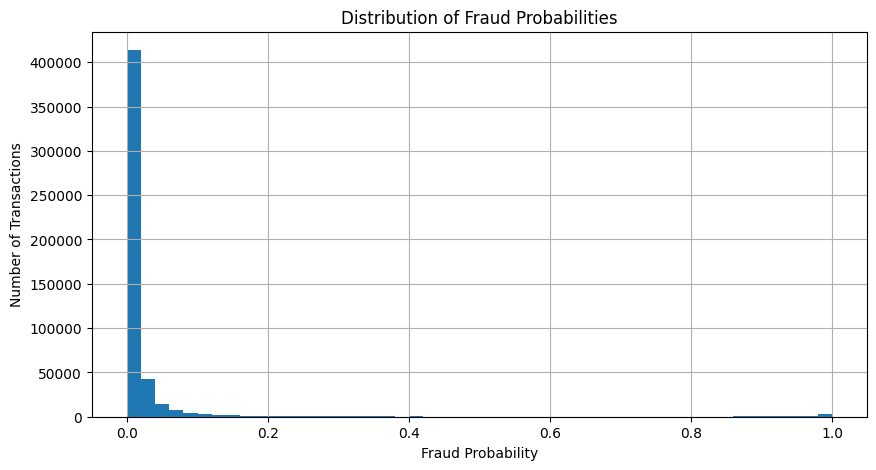

In [ ]:
import pandas as pd

# Assume you already have X_test and clf (your trained model)
fraud_probs = clf.predict_proba(X_test)[:, 1]  # Probability of isFraud = 1

# Create a DataFrame to examine predictions
fraud_df = pd.DataFrame({
    'TransactionID': X_test.index,
    'FraudProbability': fraud_probs
})

# Sort by highest probability of fraud
fraud_df_sorted = fraud_df.sort_values(by='FraudProbability', ascending=False)

# Show top 10 most suspicious transactions
print("🔍 Top 10 most likely frauds:")
print(fraud_df_sorted.head(10))

# Optionally: show distribution plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(fraud_probs, bins=50)
plt.title("Distribution of Fraud Probabilities")
plt.xlabel("Fraud Probability")
plt.ylabel("Number of Transactions")
plt.grid(True)
plt.show()

**Observations:**
xhlulu provides an efficient approach to training an XGBoost model using GPU acceleration. While his code effectively demonstrates rapid training, several enhancements—such as advanced feature engineering, class imbalance handling, hyperparameter tuning, and reproducibility improvements—can significantly boost model performance and robustness.

*  Raw Feature Usage Without Engineering:
The model is trained on mostly raw features without any deep preprocessing or feature engineering. This risks underfitting subtle fraud signals, especially temporal or user-level behavior.


*   No Feature Importance Analysis or Model Interpretation: Lacks post-training diagnostics to understand feature contributions. For fraud detection, knowing which features drive predictions is crucial for debugging, trust, and compliance.


*   No Aggregation or Time-Based Features: Transaction time (TransactionDT) is dropped, and no UID, temporal, or statistical aggregates are introduced. This skips major signal opportunities suc as transaction frequency spikes, behavioral drift.


*   Minimal Cross-Validation: A single hold-out validation set increases risk of overfitting or underfitting due to lack of robust performance sampling. Especially concerning with imbalanced datasets:
*   No Custom Threshold Tuning: The model doesn't explore adjusting the decision threshold based on cost-sensitive metrics such as optimize for F1, precision at a fixed recall. In fraud detection, threshold tuning is key.









**Conclusions:** xhlulu’s code offers a fast and clean approach to training an XGBoost model using GPU acceleration, making it a strong starting point for fraud detection tasks. However, the model could be enhanced by incorporating feature engineering techniques such as UID-based aggregations, time-based features, and frequency encoding to capture behavioral patterns. It would also benefit from addressing class imbalance more directly, using stratified cross-validation, and exploring threshold tuning beyond ROC AUC—especially in a fraud context where precision and recall matter most. With these updates, the code could evolve from a performance-focused prototype into a production-grade fraud detection pipeline.